# Week 1 – Problem Definition and Dataset Exploration
### Cardiovascular Disease Risk Prediction


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("cardio_train.csv", sep=';')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [29]:
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [30]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No found.")

No found.


In [31]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [20]:
df['age_years'] = (df['age'] / 365).round(1)
df[['age', 'age_years']].head()

,age,age_years
0,18393,50.4
1,20228,55.4
2,18857,51.7
3,17623,48.3
4,17474,47.9



### Age Distribution

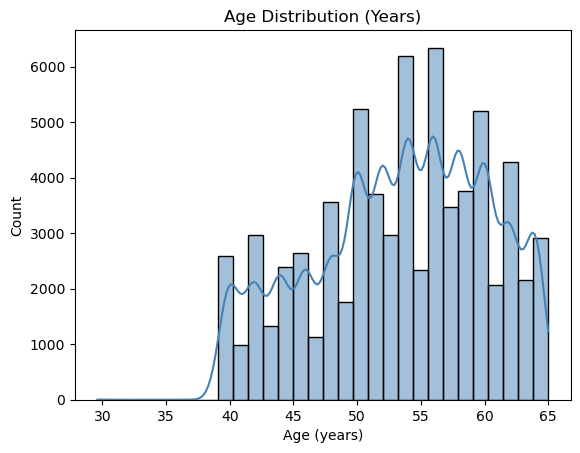

Age range: 29.6 to 65.0 years


In [21]:
sns.histplot(df['age_years'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution (Years)')
plt.xlabel('Age (years)')
plt.show()

print("Age range: {:.1f} to {:.1f} years".format(df['age_years'].min(), df['age_years'].max()))

### 5.3 Height and Weight – Potential Outliers

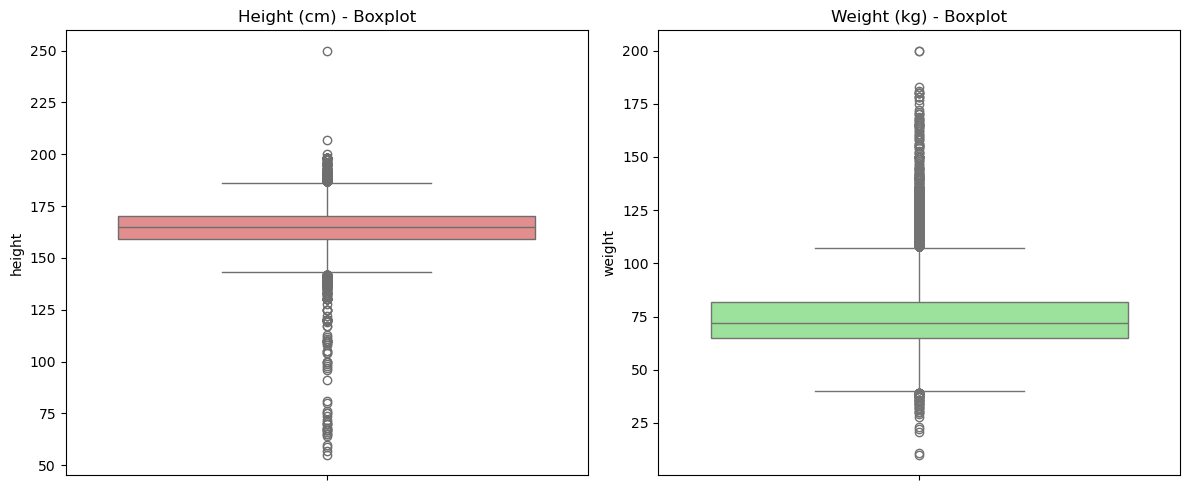

Height range: 55 - 250 cm
Weight range: 10.0 - 200.0 kg


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['height'], ax=axes[0], color='lightcoral')
axes[0].set_title('Height (cm) - Boxplot')
sns.boxplot(y=df['weight'], ax=axes[1], color='lightgreen')
axes[1].set_title('Weight (kg) - Boxplot')
plt.tight_layout()
plt.show()

print("Height range:", df['height'].min(), "-", df['height'].max(), "cm")
print("Weight range:", df['weight'].min(), "-", df['weight'].max(), "kg")

### 5.4 Blood Pressure – Potential Data Entry Errors

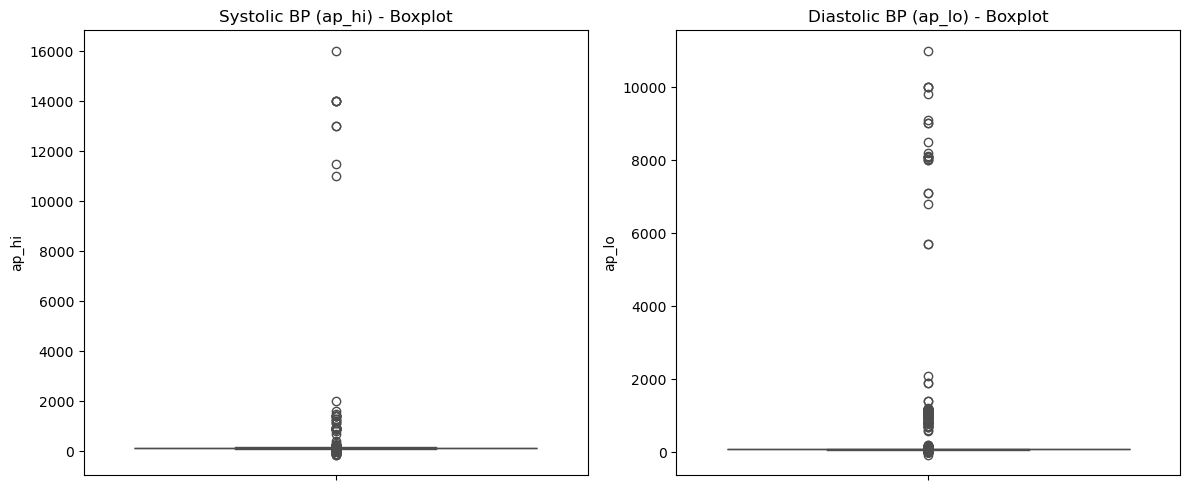

ap_hi range: -150 16020
ap_lo range: -70 11000


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['ap_hi'], ax=axes[0], color='orange')
axes[0].set_title('Systolic BP (ap_hi) - Boxplot')
sns.boxplot(y=df['ap_lo'], ax=axes[1], color='gold')
axes[1].set_title('Diastolic BP (ap_lo) - Boxplot')
plt.tight_layout()
plt.show()

print("ap_hi range:", df['ap_hi'].min() , df['ap_hi'].max())
print("ap_lo range:", df['ap_lo'].min(), df['ap_lo'].max())